In [1]:
import zipfile

zip_ref = zipfile.ZipFile('/content/images.zip', 'r')

zip_ref.extractall('/content')

zip_ref.close()

print("ZIP Extracted Successfully")

ZIP Extracted Successfully


In [2]:
import os

print(os.listdir('/content/images'))

['.DS_Store', 'normal', 'stain', 'dent', 'scratch']


In [3]:
!pip install tensorflow

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

from sklearn.metrics import confusion_matrix

In [5]:
dataset_path = "/content/images"

# Task 1: Problem Identification

This dataset represents an Image Classification problem.

Reason:
- Each image belongs to one category.
- Images are divided into four classes:
  - normal
  - scratch
  - dent
  - stain
- The CNN predicts one label for each image.

In [6]:
classes = os.listdir(dataset_path)

print("Classes:", classes)

print("Total Classes:", len(classes))

Classes: ['.DS_Store', 'normal', 'stain', 'dent', 'scratch']
Total Classes: 5


In [12]:
for cls in classes:
    path = os.path.join(dataset_path, cls)
    if os.path.isdir(path): # Ensure the path is a directory
        print(cls, ":", len(os.listdir(path)))


normal : 120
stain : 120
dent : 120
scratch : 120


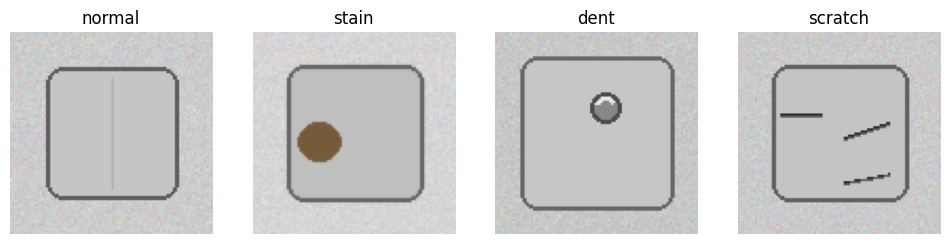

In [13]:
plt.figure(figsize=(12,8))

plot_idx = 0 # Initialize a counter for subplots
for i, cls in enumerate(classes):

    path = os.path.join(dataset_path, cls)

    # Only process if 'path' is a directory
    if os.path.isdir(path):
        plot_idx += 1 # Increment only for valid directories
        image_name = os.listdir(path)[0]

        image_path = os.path.join(path, image_name)

        img = plt.imread(image_path)

        plt.subplot(1,4,plot_idx) # Use plot_idx here

        plt.imshow(img)

        plt.title(cls)

        plt.axis('off')

plt.show()

In [15]:
for cls in classes:

    path = os.path.join(dataset_path, cls)

    # Check if the path is a directory before proceeding
    if os.path.isdir(path):
        image_name = os.listdir(path)[0]

        image_path = os.path.join(path, image_name)

        img = Image.open(image_path)

        print(cls, ":", img.size)

normal : (96, 96)
stain : (96, 96)
dent : (96, 96)
scratch : (96, 96)


# Dataset Imbalance

The dataset was checked by counting the number of images in each class. If one class contains significantly more images than others, the dataset is considered imbalanced.

# Task 3: Image Preprocessing

The following preprocessing techniques were applied:
- Resized images to 128x128
- Normalized pixel values
- Split data into training and validation sets
- Applied augmentation techniques such as rotation and flipping

In [16]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [17]:
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 384 images belonging to 4 classes.


In [18]:
val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 96 images belonging to 4 classes.


val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

In [22]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(train_data.num_classes, activation='softmax')) # Use train_data.num_classes for correct output units

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 4), output.shape=(None, 5)

In [23]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    verbose=1
)

ValueError: You must call `compile()` before using the model.

In [24]:
print(classes)

['.DS_Store', 'normal', 'stain', 'dent', 'scratch']


In [25]:
classes = [c for c in os.listdir(dataset_path) if not c.startswith('.')]

print(classes)
print("Total Classes:", len(classes))

['normal', 'stain', 'dent', 'scratch']
Total Classes: 4


In [26]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(len(classes), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 990ms/step - accuracy: 0.2682 - loss: 2.9414 - val_accuracy: 0.2708 - val_loss: 1.3802
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 946ms/step - accuracy: 0.3490 - loss: 1.3772 - val_accuracy: 0.5625 - val_loss: 1.3580
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 933ms/step - accuracy: 0.4062 - loss: 1.3146 - val_accuracy: 0.4271 - val_loss: 1.2690
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 959ms/step - accuracy: 0.4219 - loss: 1.2474 - val_accuracy: 0.4062 - val_loss: 1.1915
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 925ms/step - accuracy: 0.5938 - loss: 1.0289 - val_accuracy: 0.6042 - val_loss: 0.9698
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 885ms/step - accuracy: 0.6615 - loss: 0.8786 - val_accuracy: 0.7083 - val_loss: 0.8079
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 892ms/step - accuracy: 0.7448 - loss: 0.7130 - val_accuracy: 0.7604 - val_loss: 0.6397
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 969ms/step - accuracy: 0.7891 - loss: 0.5768 - val_accu

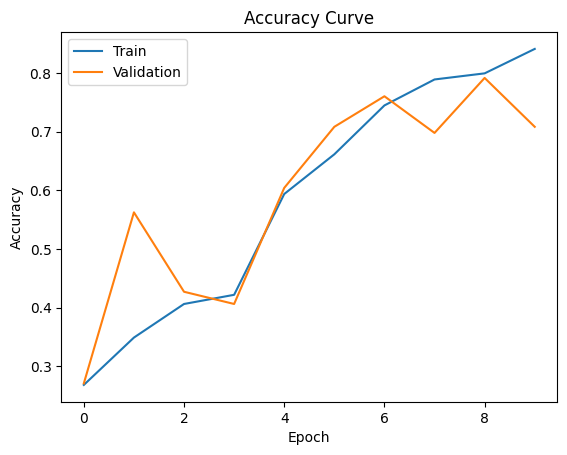

In [29]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Accuracy Curve')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.savefig("accuracy_loss_curves.png")

plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 541ms/step


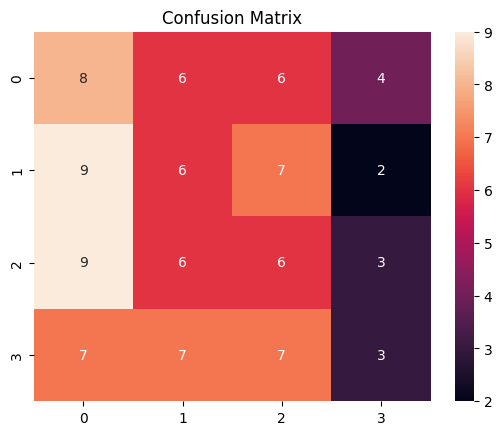

In [30]:
predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(val_data.classes, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


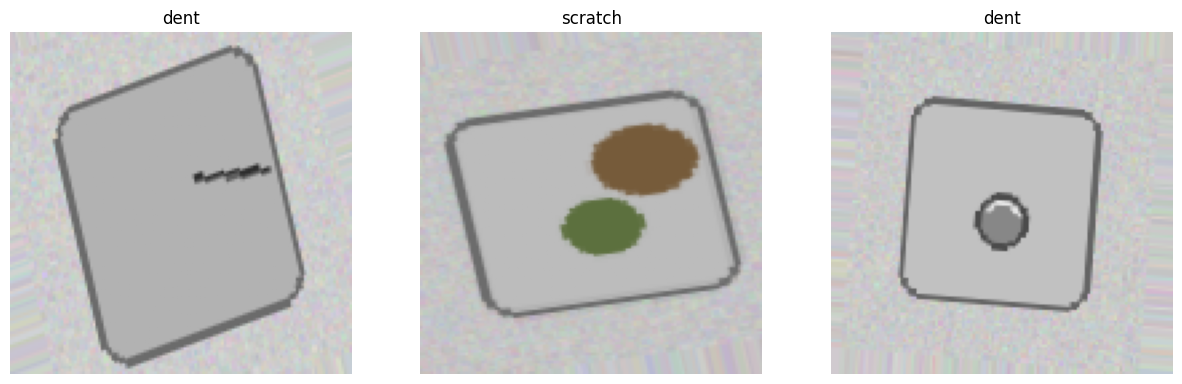

In [33]:
plt.figure(figsize=(15,10))

for i in range(len(val_data)):

    images, labels = val_data[i]

    prediction = model.predict(images)

    predicted_class = classes[np.argmax(prediction[0])]

    plt.subplot(1,len(val_data),i+1)

    plt.imshow(images[0])

    plt.title(predicted_class)

    plt.axis('off')

plt.savefig("prediction_outputs.png")

plt.show()

# Task 6: CNN Concept Explanation

## What is convolution?
Convolution uses filters to detect image patterns such as edges and textures.

## Why is pooling used?
Pooling reduces image size and computation while preserving important information.

## Why is ReLU commonly used?
ReLU helps CNNs learn complex patterns and speeds up training.

## Why are CNNs better than regular feed-forward networks?
CNNs automatically learn spatial image features and are more efficient for image data.

# Task 7: Business Use Case Mapping

This CNN-based solution can be used in manufacturing industries for automatic defect detection.

The model can identify scratches, dents, and stains on products during quality inspection, helping improve product quality and reducing manual inspection effort.